In [ ]:
#Zero-short Land Use classififation of Satellite Images Using CLIP
#Author : Jean Claude Ntabanganyimana


In [ ]:
#Configuration
import torch
print("Pytorch Version:",torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
print(torch.cuda.get_device_name(0))

Pytorch Version: 2.11.0+cu128
Using device: cuda
Tesla T4


In [ ]:
#Importing the libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import EuroSAT
from torchvision import transforms
print("Libararies import successfully")

Libararies import successfully


In [ ]:
#The cell above we imported the needed libraries to implement the project
#torch for deep learning
#numpy for numerical operations
#matplotlib for data visualization
#EuroSAT for satellite images
#transforms for preparing the images for CLIP

In [ ]:
#Loading EuroSAT dataset
transform=transforms.Compose([transforms.Resize((224,224)),
                              transforms.ToTensor()])
dataset = EuroSAT(
    root="./data",
    download=True,
    transform=transform
)
print("Number of images:", len(dataset))
print("Classes:")
print(dataset.classes)


100%|██████████| 94.3M/94.3M [00:01<00:00, 72.1MB/s]


Number of images: 27000
Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


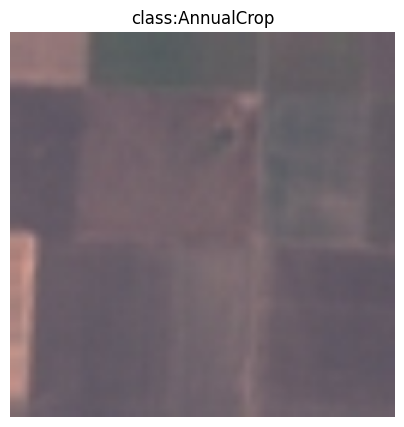

In [ ]:
#Let's visualize one Image
image,label=dataset[0]
plt.figure(figsize=(5,5))
plt.imshow(image.permute(1,2,0))
plt.title(f"class:{dataset.classes[label]}")
plt.axis("off")
plt.show()


In [ ]:
#LOAD CLIP
from transformers import CLIPModel,CLIPProcessor
model_name="openai/clip-vit-base-patch32"
model=CLIPModel.from_pretrained(model_name)
processor=CLIPProcessor.from_pretrained(model_name)
model.to(device)
print("CLIP loaded successfully")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded successfully


In [ ]:
classes=["annual crop",
    "forest",
    "herbaceous vegetation",
    "highway",
    "industrial area",
    "pasture",
    "permanent crop",
    "residential area",
    "river",
    "sea lake"]

prompts=[f"a satellite image of {c}"
         for c in classes]
for p in prompts:
  print(p)

a satellite image of annual crop
a satellite image of forest
a satellite image of herbaceous vegetation
a satellite image of highway
a satellite image of industrial area
a satellite image of pasture
a satellite image of permanent crop
a satellite image of residential area
a satellite image of river
a satellite image of sea lake


In [ ]:
text_inputs = processor(
    text=prompts,
    return_tensors="pt",
    padding=True
)


text_inputs = {
    k: v.to(device)
    for k, v in text_inputs.items()
}


with torch.no_grad():

    text_outputs = model.text_model(
        **text_inputs
    )

text_features = text_outputs.pooler_output


text_features.shape

torch.Size([10, 512])

In [ ]:
image, label = dataset[0]

print("True class:", dataset.classes[label])

True class: AnnualCrop


In [ ]:
image_inputs = processor(
    images=image,
    return_tensors="pt"
)

image_inputs = {
    k: v.to(device)
    for k, v in image_inputs.items()
}

print(image_inputs["pixel_values"].shape)

torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():

    image_outputs = model.vision_model(
        **image_inputs
    )

    image_features = model.visual_projection(
        image_outputs.pooler_output
    )


print(image_features.shape)

torch.Size([1, 512])


In [ ]:
image_features = image_features / image_features.norm(
    dim=-1,
    keepdim=True
)

text_features = text_features / text_features.norm(
    dim=-1,
    keepdim=True
)

In [ ]:
similarity = image_features @ text_features.T

print(similarity)

tensor([[ 0.0372,  0.0089,  0.0235, -0.0025, -0.0085, -0.0048,  0.0131, -0.0391,
          0.0011, -0.0184]], device='cuda:0')


In [ ]:
prediction = similarity.argmax().item()

print("Predicted:", classes[prediction])
print("True:", dataset.classes[label])

Predicted: annual crop
True: AnnualCrop
